In [1]:
import pandas as pd 
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
conn=sqlite3.connect("/Users/mohit/Desktop/invoice-intelligence-system/data/inventory.db")
tables=pd.read_sql_query("select name from sqlite_master where type='table'",conn)
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [3]:
for table in tables['name']:
    print("Table name", {table})
    df = pd.read_sql_query(f"select * from {table} limit 5", conn)
    print(df.head())

Table name {'purchases'}
           InventoryId  Store  Brand                   Description   Size  \
0    69_MOUNTMEND_8412     69   8412     Tequila Ocho Plata Fresno  750mL   
1     30_CULCHETH_5255     30   5255  TGI Fridays Ultimte Mudslide  1.75L   
2    34_PITMERDEN_5215     34   5215  TGI Fridays Long Island Iced  1.75L   
3  1_HARDERSFIELD_5255      1   5255  TGI Fridays Ultimte Mudslide  1.75L   
4    76_DONCASTER_2034     76   2034     Glendalough Double Barrel  750mL   

   VendorNumber                   VendorName  PONumber      PODate  \
0           105  ALTAMAR BRANDS LLC               8124  2023-12-21   
1          4466  AMERICAN VINTAGE BEVERAGE        8137  2023-12-22   
2          4466  AMERICAN VINTAGE BEVERAGE        8137  2023-12-22   
3          4466  AMERICAN VINTAGE BEVERAGE        8137  2023-12-22   
4           388  ATLANTIC IMPORTING COMPANY       8169  2023-12-24   

  ReceivingDate InvoiceDate     PayDate  PurchasePrice  Quantity  Dollars  \
0    2024-01-0

In [4]:
vendor_df=pd.read_sql_query("select * from vendor_invoice",conn)
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


In [5]:
vendor_df[['Quantity','Freight','Dollars']].corr()

,Quantity,Freight,Dollars
Quantity,1.000000,0.946550,0.963831
Freight,0.946550,1.000000,0.985141
Dollars,0.963831,0.985141,1.000000


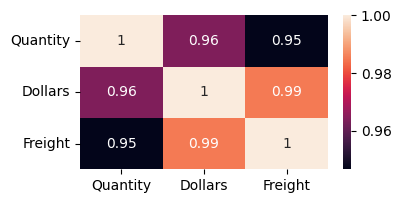

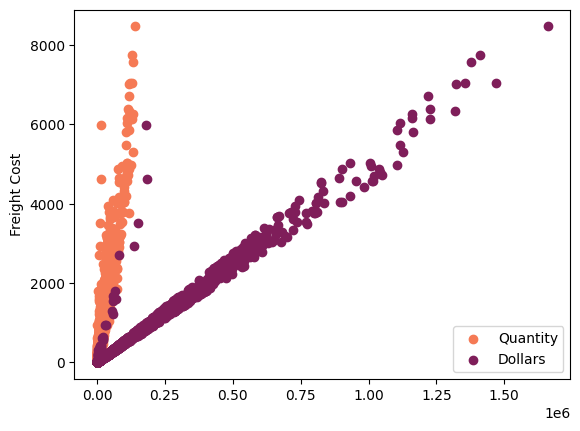

In [6]:
plt.figure(figsize=(4,2))
sns.heatmap(vendor_df[['Quantity','Dollars','Freight']].corr(),annot=True)
plt.show()

plt.scatter(vendor_df['Quantity'],vendor_df['Freight'], color = '#f57a55')
plt.scatter(vendor_df['Dollars'],vendor_df['Freight'], color='#7f1e5a')
plt.legend(['Quantity','Dollars'])
plt.ylabel('Freight Cost')
plt.show()

In [7]:
vendor_df['freight_per_unit']=vendor_df['Freight']/vendor_df['Quantity']

In [8]:
low_quantity=vendor_df['Quantity'].quantile(0.25)
high_quantity=vendor_df['Quantity'].quantile(0.75)

In [9]:
vendor_df.loc[vendor_df['Quantity']<low_quantity,'freight_per_unit'].mean()

0.09489854253138316

In [10]:
vendor_df.loc[vendor_df['Quantity']>high_quantity,'freight_per_unit'].mean()

0.049077654690759046

In [11]:
X=vendor_df[['Dollars']]
y=vendor_df['Freight']

In [12]:
vendor_df.describe().round()

,VendorNumber,PONumber,Quantity,Dollars,Freight,freight_per_unit
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,20663.0,10889.0,6059.0,58073.0,296.0,0.0
std,34582.0,1601.0,14453.0,140234.0,714.0,0.0
min,2.0,8106.0,1.0,4.0,0.0,0.0
25%,3089.0,9504.0,83.0,968.0,5.0,0.0
50%,7240.0,10890.0,423.0,4765.0,25.0,0.0
75%,10754.0,12276.0,5100.0,44587.0,230.0,0.0
max,201359.0,13661.0,141660.0,1660436.0,8468.0,3.0


In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42)

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [16]:
model1=LinearRegression()
model1.fit(X_train,y_train)

model2=DecisionTreeRegressor(random_state=42)
model2.fit(X_train,y_train)

model3=RandomForestRegressor(random_state=42)
model3.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
import numpy as np

def evaluate_model(model, X_test, y_test, model_name):
    
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds) * 100

    print(f"{model_name} Performance:")
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R2  :", r2)
    print()

In [18]:
evaluate_model(model1,X_test, y_test, "Linear Regression")
evaluate_model(model2,X_test, y_test, "Decision Tree Regressor")    
evaluate_model(model3,X_test, y_test, "Random Forest Regressor")


Linear Regression Performance:
MAE : 24.105977072875767
RMSE: 124.72096203547433
R2  : 96.98787714456559

Decision Tree Regressor Performance:
MAE : 32.647608330828575
RMSE: 163.73757505794222
R2  : 94.80852836268119

Random Forest Regressor Performance:
MAE : 28.273276444107484
RMSE: 142.21388134906886
R2  : 96.0836837360935



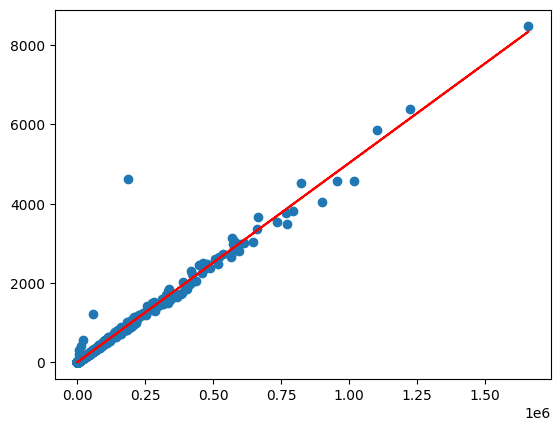

In [19]:
plt.scatter(X_test, y_test)
plt.plot(X_test, model1.predict(X_test), color='red')

In [20]:
input_data={
    "Dollars":[18500,9000]
}
df=pd.DataFrame(input_data)
model1.predict(df)

array([97.78868161, 50.14455838])